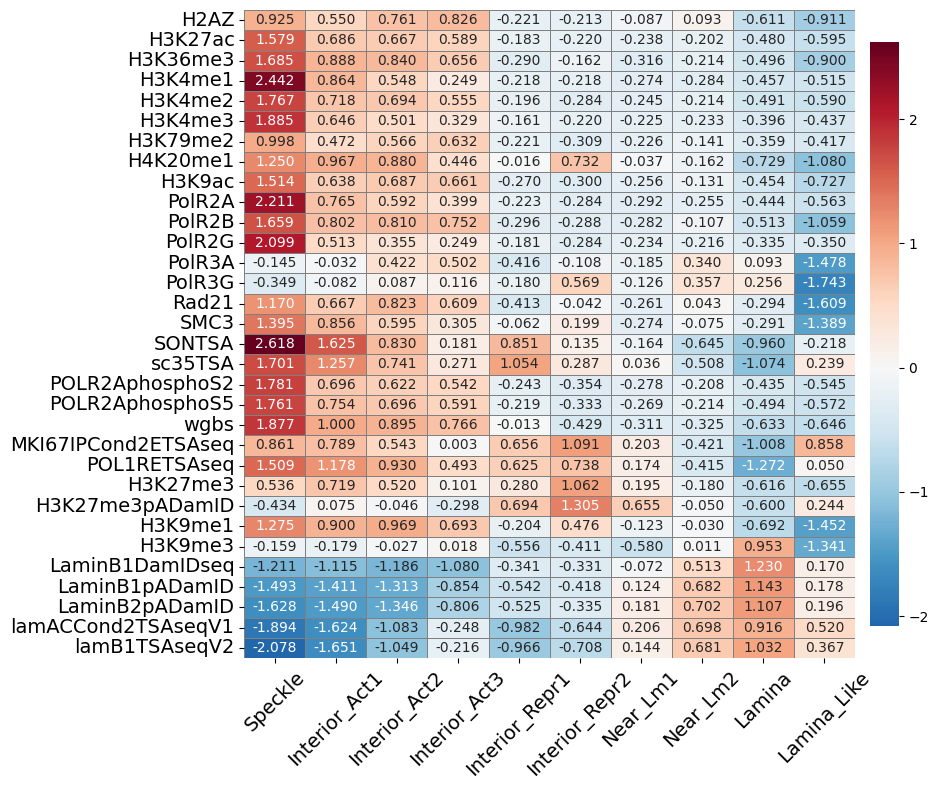

In [3]:
import bioframe as bf
import pyBigWig
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def make_binned_genome(bin_size=50000, genome='hg38'):
    """Create a binned genome dataframe for main chromosomes."""
    chromsizes = bf.fetch_chromsizes(genome)
    main_chroms = [f'chr{i}' for i in list(range(1, 23)) + ['X']]
    chromsizes = chromsizes[chromsizes.index.isin(main_chroms)]
    bins_df = bf.binnify(chromsizes, bin_size)
    return bins_df


def aggregate_bigwigs(bins_df, bigwig_dict, aggregation='mean', handle_nan='zero'):
    """Aggregate multiple bigWig files into binned genome columns."""
    bins_df = bins_df.copy()
    for column_name, bigwig_path in bigwig_dict.items():
        bw = pyBigWig.open(str(bigwig_path))
        values = []
        for _, row in bins_df.iterrows():
            try:
                stat = bw.stats(row['chrom'], int(row['start']), int(row['end']),
                                type=aggregation, nBins=1)
                value = stat[0] if stat and stat[0] is not None else np.nan
            except RuntimeError:
                value = np.nan
            values.append(value)
        bw.close()
        values = np.array(values)
        if handle_nan == 'zero':
            values = np.nan_to_num(values, nan=0.0)
        bins_df[column_name] = values
    return bins_df


def normalize_zscore(df, coord_cols=('chrom', 'start', 'end')):
    """Z-score normalize all non-coordinate columns."""
    df = df.copy()
    feature_cols = [c for c in df.columns if c not in coord_cols]
    for col in feature_cols:
        mean, std = df[col].mean(), df[col].std()
        if std > 0:
            df[col] = (df[col] - mean) / std
        else:
            print(f"  Warning: '{col}' has zero variance, keeping original values")
    return df


# ---- Run ----
bigwig_files = {
    'H2AZ_ENCFF621DJP': '/abyss/dlafonta/data/K562_data/DL/H2AFZ_R1_ENCFF621DJP.bigWig',
    'H3K27ac_ENCFF849TDM': '/abyss/dlafonta/data/K562_data/DL/H3K27ac_R1_ENCFF849TDM.bigWig',
    'H3K36me3_ENCFF347YYH': '/abyss/dlafonta/data/K562_data/DL/H3K36me3_R2_ENCFF347YYH.bigWig',
    'H3K4me1_ENCFF399SGM': '/abyss/dlafonta/data/K562_data/DL/H3K4me1_R1_ENCFF399SGM.bigWig',
    'H3K4me2_ENCFF959YJV': '/abyss/dlafonta/data/K562_data/DL/H3K4me2_R1_ENCFF959YJV.bigWig',
    'H3K4me3_ENCFF806YEZ': '/abyss/dlafonta/data/K562_data/DL/H3K4me3_R2_ENCFF806YEZ.bigWig',
    'H3K79me2_ENCFF957YJT': '/abyss/dlafonta/data/K562_data/DL/H3K79me2_R1_ENCFF957YJT.bigWig',
    'H4K20me1_ENCFF605FAF': '/abyss/dlafonta/data/K562_data/DL/H4K20me1_R1_ENCFF605FAF.bigWig',
    'H3K9ac_ENCFF286WRJ': '/abyss/dlafonta/data/K562_data/DL/H3K9ac_R2_ENCFF286WRJ.bigWig',
    'PolR2A_ENCFF348QLX': '/abyss/dlafonta/data/K562_data/DL/POLR2A_R3_ENCFF348QLX.bigWig',
    'PolR2B_ENCFF331WPU': '/abyss/dlafonta/data/K562_data/DL/POLR2B_R1_ENCFF331WPU.bigWig',
    'PolR2G_ENCFF923SQO': '/abyss/dlafonta/data/K562_data/DL/POLR2G_R2_ENCFF923SQO.bigWig',
    'PolR3A_ENCFF355ULG': '/abyss/dlafonta/data/K562_data/DL/POLR3A_R1_ENCFF355ULG.bigWig',
    'PolR3G_ENCFF462VCE': '/abyss/dlafonta/data/K562_data/DL/POLR3G_R1_ENCFF462VCE.bigWig',
    'Rad21_ENCFF851FYN': '/abyss/dlafonta/data/K562_data/DL/Rad21_R12_ENCFF851FYN.bigWig',
    'SMC3_ENCFF479BWQ': '/abyss/dlafonta/data/K562_data/DL/SMC3_R12_ENCFF479BWQ.bigWig',
    'SONTSA_4DNFINVM6LFT': '/abyss/dlafonta/data/K562_data/DL/SONCond2_TSAseqV1_R1_4DNFINVM6LFT.bw',
    'sc35TSA_4DNFIXWDLHDL': '/abyss/dlafonta/data/K562_data/DL/TSAseq_pSC35_4DNFIXWDLHDL.bw',
    'POLR2AphosphoS2_ENCFF434PYZ': '/abyss/dlafonta/data/K562_data/DL/POLR2AphosphoS2_R2_ENCFF434PYZ.bigWig',
    'POLR2AphosphoS5_ENCFF907FLD': '/abyss/dlafonta/data/K562_data/DL/POLR2AphosphoS5_R1_ENCFF907FLD.bigWig',
    'wgbs_ENCFF669KCI': '/abyss/dlafonta/data/K562_data/DL/wgbs_signal_ENCFF669KCI.bigWig',
    'MKI67IPCond2ETSAseq_4DNFI7FRDW2J': '/abyss/dlafonta/data/K562_data/DL/MKI67IPCond2E_TSAseq_R2_4DNFI7FRDW2J.bw',
    'POL1RETSAseq_4DNFI1WULK53': '/abyss/dlafonta/data/K562_data/DL/TSAseq_POL1RE_4DNFI1WULK53.bw',
    'H3K27me3_ENCFF139KZL': '/abyss/dlafonta/data/K562_data/DL/H3K27me3_R2_ENCFF139KZL.bigWig',
    'H3K27me3pADamID_4DNFIN7A5KQ2': '/abyss/dlafonta/data/K562_data/DL/H3K27me3_pADamID_R1_4DNFIN7A5KQ2.bw',
    'H3K9me1_ENCFF654SLZ': '/abyss/dlafonta/data/K562_data/DL/H3K9me1_R1_ENCFF654SLZ.bigWig',
    'H3K9me3_ENCFF601JGK': '/abyss/dlafonta/data/K562_data/DL/H3K9me3_R1_ENCFF601JGK.bigWig',
    'LaminB1DamIDseq_4DNFI6QDHEP2': '/abyss/dlafonta/data/K562_data/DL/LaminB1_DamIDseq_R1_4DNFI6QDHEP2.bw',
    'LaminB1pADamID_4DNFIOJ9ID9U': '/abyss/dlafonta/data/K562_data/DL/LaminB1_pADamID_R2_4DNFIOJ9ID9U.bw',
    'LaminB2pADamID_4DNFIVSWYND6': '/abyss/dlafonta/data/K562_data/DL/LaminB2_pADamID_merge_4DNFIVSWYND6.bw',
    'lamACCond2TSAseqV1_4DNFII37TNR5': '/abyss/dlafonta/data/K562_data/DL/lamACCond2_TSAseqV1_R1_4DNFII37TNR5.bw',
    'lamB1TSAseqV2_4DNFIXC534XS': '/abyss/dlafonta/data/K562_data/DL/lamB1_TSAseqV2_R2_4DNFIXC534XS.bw',
}

bins = make_binned_genome(bin_size=50000, genome='hg38')
df = aggregate_bigwigs(bins, bigwig_files, aggregation='mean')
df = normalize_zscore(df)

# ---- Bind SPIN data ----
SPIN = pd.read_csv('/abyss/dlafonta/data/K562_data/SPIN/K562_SPIN_hg38_allbins_50kb_originaldata.bed',
                   sep='\t', header=0)
merged_df = pd.merge(SPIN, df, on=['chrom', 'start', 'end'], how='inner')


# ============ PLOT ============
df = merged_df

exclude_cols = ['chrom', 'start', 'end', 'SPIN']
histone_cols = [col for col in df.columns if col not in exclude_cols]

grouped_data = df.groupby('SPIN')[histone_cols].mean()

spin_order = ['Speckle','Interior_Act1','Interior_Act2','Interior_Act3','Interior_Repr1','Interior_Repr2','Near_Lm1','Near_Lm2','Lamina','Lamina_Like']
grouped_data = grouped_data.reindex(spin_order)

heatmap_data = grouped_data.T
heatmap_data.columns.name = None

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, 
            cmap='RdBu_r',
            center=0,
            annot=True,
            fmt='.3f',
            cbar_kws={'label': '', 'shrink': 0.9, 'pad': 0.02},
            linewidths=0.5,
            linecolor='gray')

clean_labels = [col.split('_')[0] for col in histone_cols]

plt.yticks(np.arange(len(clean_labels)) + 0.5, clean_labels, rotation=0, fontsize=14)
plt.xticks(np.arange(len(spin_order)) + 0.5, spin_order, rotation=45, fontsize=14)

plt.tight_layout()
plt.savefig('spin_heatmap2.png', dpi=300, bbox_inches='tight')
plt.show()
